### Image matching

Lorsqu'on effectue une recherche d'images d'un objet unique particulier, on s'attend bien naturellement à ce que les résultats le présentent sous des formes variées.

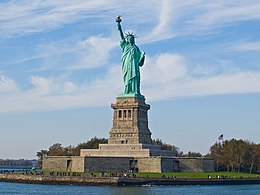
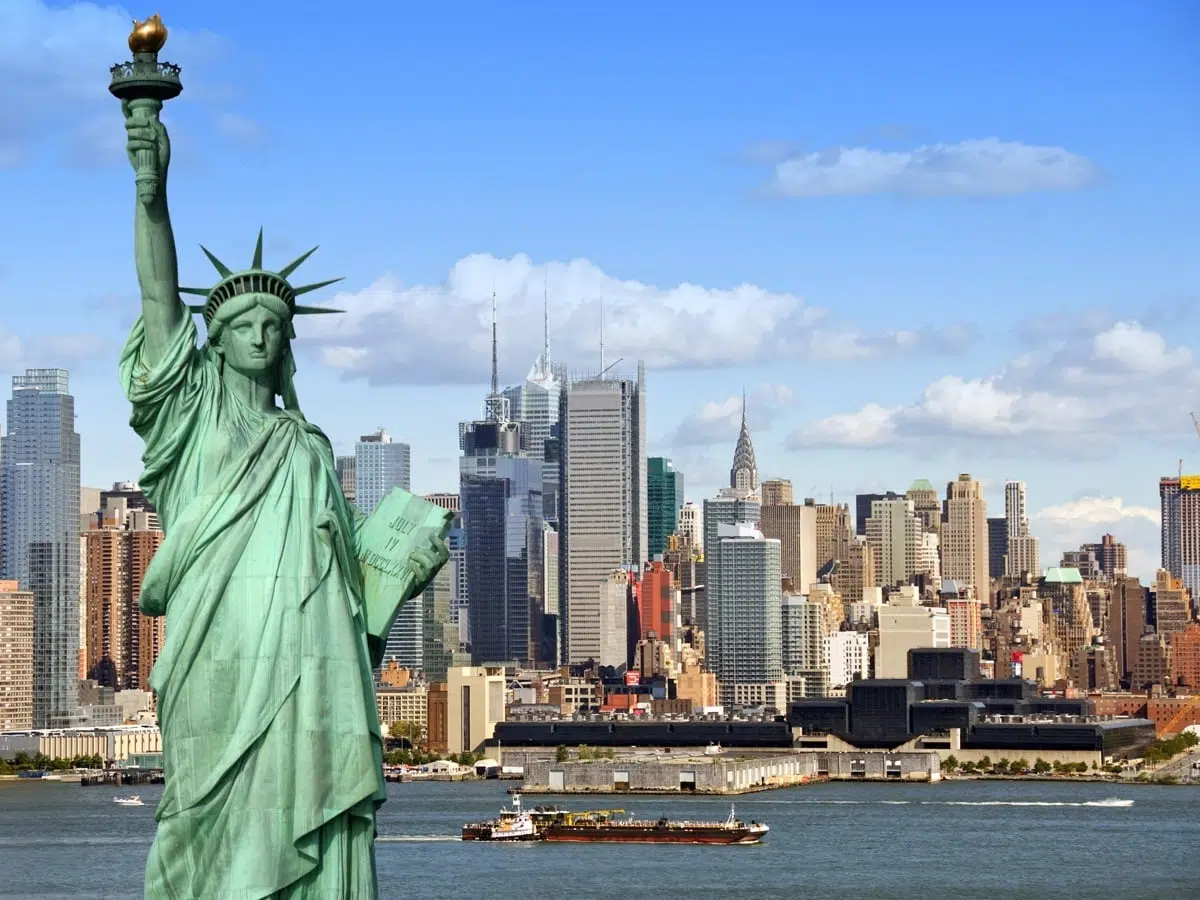
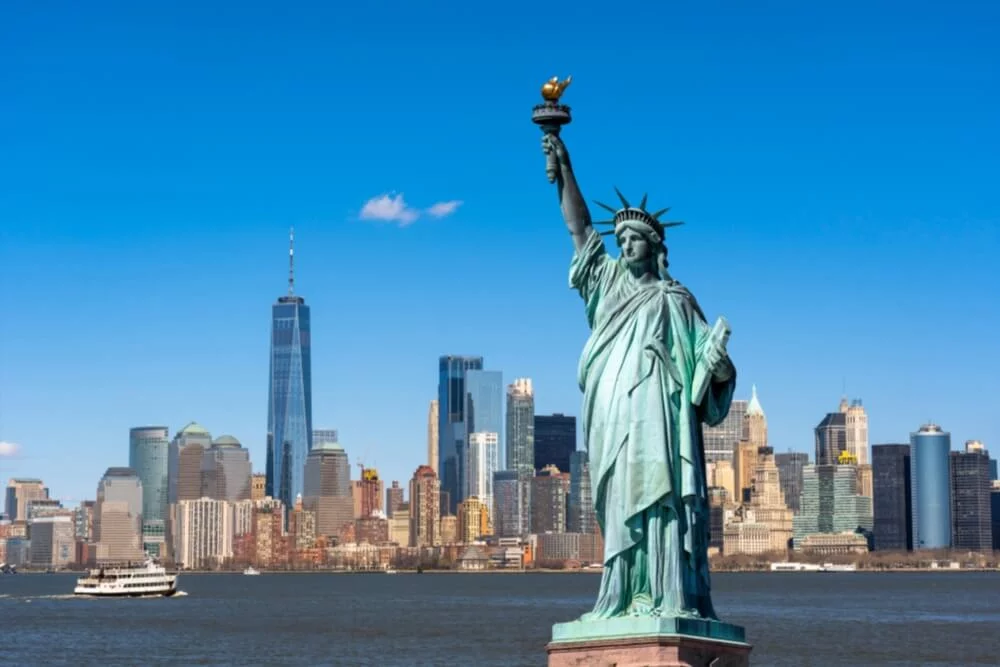
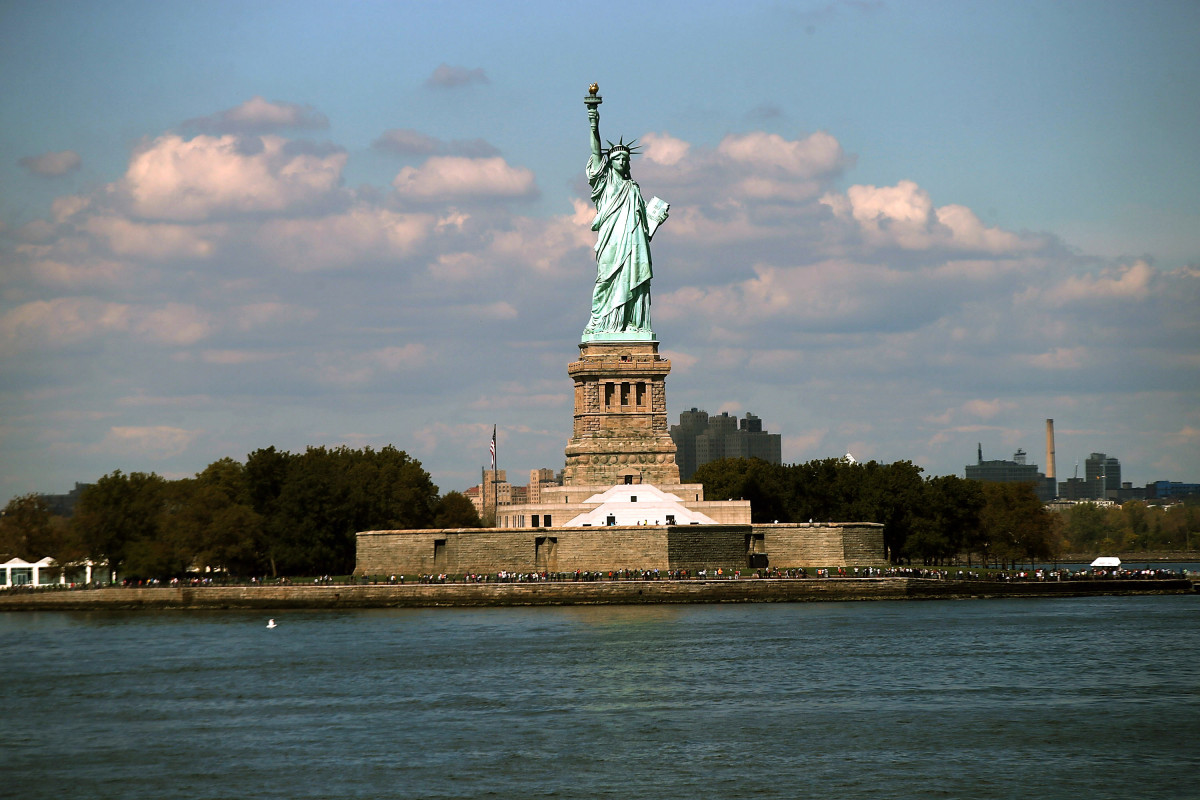

Plusieurs éléments peuvent différer d'une photo à l'autre, notamment :

- L'angle de capture (résultant d'une transformation affine ou d'une projection).
- L'orientation (résultat d'une rotation).
- L'échelle (résultat d'un zoom).
- Les propriétés photométriques, telles que la luminosité et le contraste, qui varient en fonction de l'heure de la journée, de la météo, de l'utilisation du flash...
- L'occultation, où une partie de l'image est cachée.
- Les éléments de confusion de l'arrière-plan, où une partie de l'image peut se mêler avec des éléments situés en arrière-plan.

Il existe diverses méthodes pour transformer une image en une autre. Parmi celles-ci, les transformations dites géométriques altèrent la disposition des pixels. Les manipulations d'histogrammes permettent elles de corriger la luminosité et le contraste.

Lorsque deux images appartiennent à la même catégorie, c'est-à-dire qu'elles représentent la même chose, elles sont inévitablement liées par une transformation. Cependant, la caractérisation précise de cette transformation demeure inconnue.

Comment peut-on déterminer la transformation qui permet de passer d'une image à une autre ? C'est là qu'intervient un problème classique en vision par ordinateur, appelé "image matching," qui trouve des applications dans la création de panoramas, la détection d'images similaires, la reconnaissance d'objets dans une image...

Au lieu de chercher à élaborer une équation mathématique précise pour la transformation (ce que nous faisons quand nous définissions nos filtres), l'approche adoptée consiste à identifier les éléments communs aux deux images. La question fondamentale devient alors la suivante : quels sont les caractéristiques distinctives de l'image 1, et sont-elles présentes dans l'image 2 ?

Cette tâche peut sembler relativement simple pour notre cerveau, mais elle représente un défi de taille pour un ordinateur, qui doit être en mesure de décrire les spécificités d'une catégorie d'images malgré les variations potentielles énumérées précédemment.

Même si nous n'allons pas déterminer d'équation explicite de la transformation, l'approche repose malgré tout sur le principe de filtrage. Les filtres sont des instruments efficaces pour réduire le bruit dans une image, mais ils sont aussi utilisés pour repérer des motifs spécifiques. Ces motifs sont généralement exprimés sous forme de petites images appelées "templates." L'objectif du template matching est de localiser ces templates au sein d'une image donnée.

Lorsqu'on applique le template matching avec des filtres, on recourt à l'opérateur de corrélation croisée, noté ⊗. Cet opérateur opère en transformant une image représentée sous forme matricielle, notée $ X $, en une nouvelle image, nommée $ Y $, selon la formule suivante :

$ Y_{i,j} = \sum \limits_{u=−k}^{k} \sum \limits_{v=−k}^{k} H_{u,v} X_{i+u,j+v} $

Dans ce contexte, $ H $ désigne une petite image (pour les physiciens, penser "imagette" en analogie au principe "d'ondelette" pour plus tard) qui représente le template que l'on cherche à localiser. En pratique, cette opération se résume à déplacer le template $ H $ sur l'image $ X $, en multipliant les pixels qui se chevauchent et en additionnant les produits obtenus.

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
from skimage import color, exposure, feature, filters, io

La formule de la corrélation croisée ressemble au produit de convolution. <font color="orange">Quelle est la différence entre ces deux opérateurs ?</font>

In [ ]:
# Votre réponse ici

<font color="orange">Charger les images charlie_template et charlie_scene, les convertir en niveaux de gris et les visualiser. Afficher leur taille.</font>

In [ ]:
charlie_template = io.imread(...)
grey_charlie_template = color.rgb2gray(charlie_template)
charlie_scene = io.imread(...)
grey_charlie_scene = color.rgb2gray(charlie_scene)
io.imshow(grey_charlie_template)
io.show()
print(grey_charlie_template.shape)
io.imshow(grey_charlie_scene)
io.show()
print(grey_charlie_scene.shape)

<font color="orange">C'est l'heure de jouer sans tricher : indiquer un ordre de grandeur de la position du template dans l'image.</font>

In [ ]:
# Votre réponse ici

<font color="orange">Trouver dans le module feature de scikit-image la fonction la plus adaptée pour faire du template matching. L'appliquer aux images de Où est Charlie et visualiser la sortie (la carte de corrélation).</font>

In [ ]:
cross_corr_charlie = <module-à-trouver>.<fonction-à-trouver>(image=..., template=...)
io.imshow(cross_corr_charlie)
io.show()

<font color="orange">Repérer le point de cross-correlation maximale dans cette sortie.</font>

In [ ]:
y, x = np.unravel_index(cross_corr_charlie.argmax(), cross_corr_charlie.shape)
print(y, x)

<font color="orange">Faire apparaître le template en niveaux de gris sur une image au fond noir, au niveau de sa position sur l'image de départ.</font>

In [ ]:
feature.peak_local_max(...)[0]

<font color="orange">Rassembler les éléments de code précédents dans une fonction prenant en entrée une image et un template, renvoyant la position du template dans l'image tout en affichant le template gris sur le fond noir comme précédemment.</font>

In [ ]:
# Votre code ici

<font color="orange">L'appeler sur Charlie.</font>

In [ ]:
# Votre code ici

<font color="orange">L'essayer sur le cas Charlie 2.</font>

In [ ]:
# Votre code ici

Il est temps de chercher ouaf. <font color="orange">Essayer la fonction sur le cas Charlie 3.</font>

In [ ]:
# Votre code ici

<font color="orange">Commenter les limites de nos filtres Charlie.</font>

In [ ]:
# Votre réponse ici

 C'est à ce stade que la notion de "features" (caractéristiques) d'une image entre en jeu. Ce terme fait référence à des zones spécifiques d'une image numérique qui suscitent un intérêt particulier. Ces zones peuvent correspondre à des contours, des points saillants ou des régions d'intérêt. Chaque feature détectée est associée à un vecteur appelé "descripteur" (ou "feature descriptor" / "feature vector"). Comme son nom l'indique, ce descripteur renferme des informations pour caractériser la zone en question.

La résolution du problème d'image matching s'articule alors autour de deux étapes principales :

- La détection et la description des features dans chaque image.
- La recherche de paires de features correspondantes dans les deux images (appelée "features matching").

La qualité des résultats obtenus grâce à l'algorithme d'image matching repose sur la pertinence des features détectées. En ce sens, la première étape revêt une importance cruciale et ne doit pas être négligée.

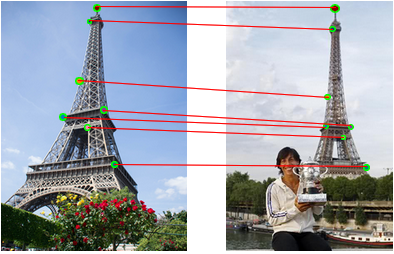

La détection et la description des features constituent la première étape indispensable pour de nombreuses tâches en computer vision, y compris la classification d'images, que nous étudierons plus en détail durant la formation dans un prochain TP.


Naturellement, un choix inadéquat de features peut entraîner deux problèmes majeurs lors de l'étape de matching :

- Deux images peuvent ne pas avoir les mêmes features, même si elles représentent la même scène de différentes manières.
- Deux images peuvent présenter les mêmes features, mais il peut être extrêmement difficile de trouver les paires correspondantes entre elles.

Ces deux problèmes peuvent rendre le matching impossible, et c'est pourquoi il est essentiel d'anticiper ces défis dès la première étape, lors de la détection et de la description des features.

Cela nous amène à la question fondamentale : quelles features faut-il sélectionner ?

Les features appropriées doivent répondre à plusieurs critères :

- <b>Répétabilité</b> : Les features doivent être reconnaissables dans les images représentant la même scène, malgré les variations géométriques et photométriques. Elles doivent donc être invariantes à ces transformations.
- <b>Distinctivité</b> : Les features doivent être uniques et clairement identifiables au sein d'une image pour faciliter le matching. Les informations contenues dans leur descripteur doivent mettre en évidence leur singularité.
- <b>Localité</b> : Les features doivent correspondre à des zones de taille suffisamment réduite et doivent être décrites en fonction de leur voisinage immédiat. Cela permet de surmonter les problèmes liés à l'occlusion et aux éléments de confusion en arrière-plan.
- <b>Abondance</b> : Un grand nombre de features détectées est souhaitable, mais il est essentiel que leur nombre total reste inférieur au nombre de pixels de l'image pour garantir l'efficacité de l'algorithme de matching.

En résumé, pour être considérée comme une "bonne" feature, une caractéristique doit être à la fois suffisamment distinctive pour différencier des classes d'images différentes et suffisamment générique pour permettre la reconnaissance aisée d'images de la même classe, malgré les variations dans leurs représentations.

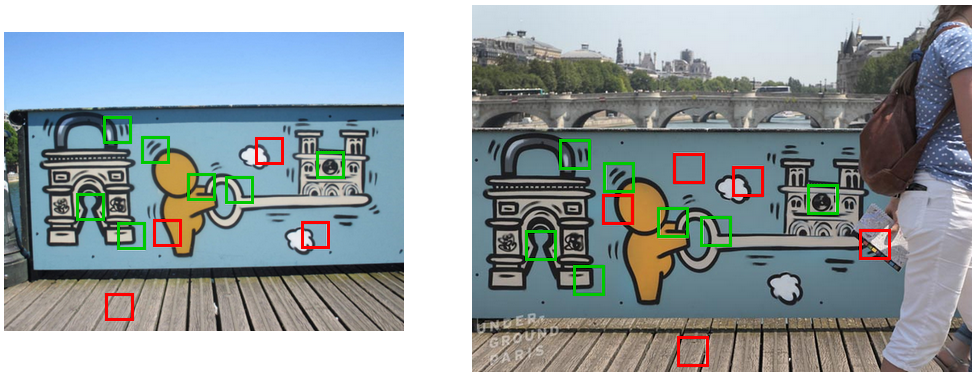

### Gradient

Cette section peut être passée par les personnes qui ne sont pas particulièrement intéressées par les quelques aspects mathématiques derrière la création pratique de features ou, au contraire, ceux qui sont familiers avec cette notion de gradient.

Le gradient d'une image est un outil précieux pour détecter des caractéristiques. Il s'agit d'un vecteur composé des dérivées partielles de la fonction d'intensité calculées pour chaque pixel :

$ ∇I(x, y) = \begin{bmatrix} \frac{∂I(x, y)}{∂x} \\ \frac{∂I(x, y)}{∂y} \end{bmatrix}$

La dérivée partielle par rapport à x (respectivement y) nous permet d'analyser les variations d'intensité de l'image le long de l'axe des abscisses (respectivement des ordonnées).

Le gradient pointe dans la direction où l'intensité varie le plus dans le voisinage du pixel (x, y) :
$ Θ = \arctan(\frac{\frac{∂I(x, y)}{∂y}}{\frac{∂I(x, y)}{∂x}}) $

Sa norme indique à quel point cette variation est significative (plus elle est élevée, plus le changement est brusque) :
$ ||∇I(x, y)|| = \sqrt{(\frac{∂I(x, y)}{∂x})^2 + (\frac{∂I(x, y)}{∂y})^2} $




<font color="orange">Proposer une expression approchée du gradient en un pixel à partir des intensités des pixels de son voisinage (différences finies). En déduire deux masques de convolution ou corrélation croisée qui permettent de calculer les deux composantes de ce gradient.</font>

In [ ]:
# Votre réponse ici

<font color="orange">Imaginer une version de ces noyaux en taille 3x3 de sorte à "lisser" les variations en utilisant également la ligne du dessus et celle d'en dessous pour le gradient selon $ x $, mais pondérées deux fois moins que la ligne du pixel considéré, et de même avec les colonnes de gauche et de droite pour le gradient selon $ y $.</font>

In [ ]:
# Votre code ici

Bravo, vous venez de retrouver précisément le filtre de Sobel, très utilisé lorsqu'on a besoin d'approximer le gradient !

<font color="orange">Essayer d'imaginer une application de ce gradient pour la détection d'objets.</font>

In [ ]:
# Votre réponse ici

### Détection de bords

Un filtre très connu pour réaliser cette tâche est le filtre de Canny.

Vu que les valeurs élevées de l'amplitude du gradient indiquent des changements d'intensité importants l'objectif est de localiser les maxima locaux de la norme du gradient ||∇I||.

Le processus de détection des bords à l'aide du filtre de Canny comporte différentes étapes :

1- Réduction du bruit : Tout d'abord, il est essentiel de réduire le bruit de l'image, car les pixels ayant des valeurs aberrantes peuvent entraîner des variations d'intensité importantes qui ne correspondent pas nécessairement à des bords. On utilise généralement un filtre gaussien pour éliminer le bruit additif et un filtre médian pour les rares "pixels poivre et sel".

2- Calcul du gradient de l'image : Le gradient de l'image débruitée est obtenu en effectuant une opération de convolution, généralement avec les masques de Sobel. Cela permet de calculer l'amplitude et la direction du gradient en chaque point de l'image. Les bords sont identifiés grâce aux points présentant une forte amplitude.

3- Suppression des non-maxima : Les bords identifiés à l'étape précédente sont parfois trop épais. Afin de les affiner, on ne conserve que les points où l'amplitude du gradient est localement maximale dans la direction du gradient. Pour ce faire, on quantifie l'angle de la direction du gradient et on identifie les deux voisins de chaque pixel le long de cette direction.

4- Seuillage : Parmi les points sélectionnés à l'étape précédente, seuls ceux dont l'amplitude du gradient est supérieure à un certain seuil sont conservés. Le choix d'un seuil adéquat peut être délicat, c'est pourquoi on utilise souvent le seuillage par hystérésis, qui repose sur deux seuils, $ s_{bas} $ et $ s_{haut} $.
    - Si ||∇I(x,y)|| ≥ $ s_{haut} $, alors le pixel (x,y) est considéré comme étant sur un bord.
    - Si ||∇I(x,y)|| ≥ $ s_{bas} $, alors le pixel (x,y) est identifié comme étant sur un bord si au moins l'un de ses huit voisins l'est également.
    - Sinon, le pixel (x,y) n'est pas considéré comme faisant partie d'un bord.

<font color="orange">Tester le filtre de Canny sur une image peu bruitée. A votre avis, l'implémentation de scikit-image effectue-t-elle un lissage de bruit ou faut-il le réaliser soi-même avant d'appliquer la méthode à proprement parler ?</font>

In [ ]:
# Votre réponse ici

### Détection de coins

Les coins sont des features très riches en informations. Leur détection est basée sur le même principe que celle des contours, mais dans le cas d'un coin, l'intensité varie dans deux directions peu colinéaires.

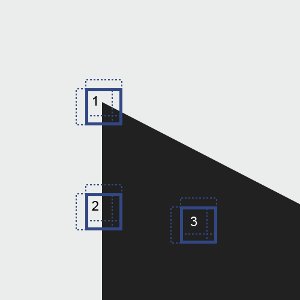

1- Dans la première situation, si la zone contient un coin, l'intensité de l'image change brusquement dans plusieurs directions, ce qui se traduit par des valeurs élevées de la fonction E dans ces différentes directions.

2- Dans la deuxième situation, si la zone contient un contour, l'intensité de l'image change rapidement en se déplaçant horizontalement, mais très peu en se déplaçant verticalement. En conséquence, la fonction E présente des valeurs élevées lorsque le déplacement est perpendiculaire au contour, mais des valeurs faibles lorsqu'il suit le contour.

3- Enfin, dans la troisième situation, en l'absence de changements d'intensité, c'est-à-dire lorsque la région est uniforme, la fonction E affiche des valeurs faibles dans toutes les directions.

On a décrit ici le principe de base du filtre de Moravec.

Un des filtres de détection de coins les plus célèbres est celui de Harris-Stephens. Il s'agit d'une amélioration du filtre de Moravec. Pour les plus curieux, voici en quoi :
- la fenêtre carrée centrée visible sur le schéma du dessus est remplacée par une fenêtre gaussienne,
- les variations d'intensité qui interviennent dans le calcul sont approximées par les dérivées partielles (développement de Taylor) elles-mêmes approximées par des filtres de Sobel vus précédemment, au lieu d'être calculées directement,
- un nouveau critère (basé sur le calcul des deux valeurs propres d'une matrice) est introduit pour déterminer si nous sommes face à un coin, un bord ou une région plate.

<font color="orange">Sur notre image de bateau, repérer la ou les zone(s) avec des coins très marqués. En sachant que coin se dit "corner" en anglais, trouver la fonction du module feature de scikit-image permettant de réaliser un filtre de Harris-Stephens (parfois simplement appelé filtre de Harris). Visualiser le résultat.</font>

In [ ]:
# Votre code ici